In [1]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
ds = xr.open_dataset('ncqs_hourly_pertransect.nc')  
dp = xr.open_dataset('dp_merged_all.nc')
angles = xr.open_dataset('angles.nc')

In [3]:
wave_lats = dp.lat.values
wave_lons = dp.lon.values
transect_lats = ds.lat.values
transect_lons = ds.lon.values

def get_nearest_indices(w_lats, w_lons, t_lats, t_lons):
    indices = []
    for lat, lon in zip(t_lats, t_lons):
        dist = np.sqrt((w_lats - lat)**2 + (w_lons - lon)**2)
        indices.append(np.argmin(dist))
    return np.array(indices)

mapping_idx = get_nearest_indices(wave_lats, wave_lons, transect_lats, transect_lons)

dp_mapped = dp.isel(site=mapping_idx).assign_coords(
    site=ds.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

In [4]:
target_site = "usa_NC_0037_0071"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/2822612818.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


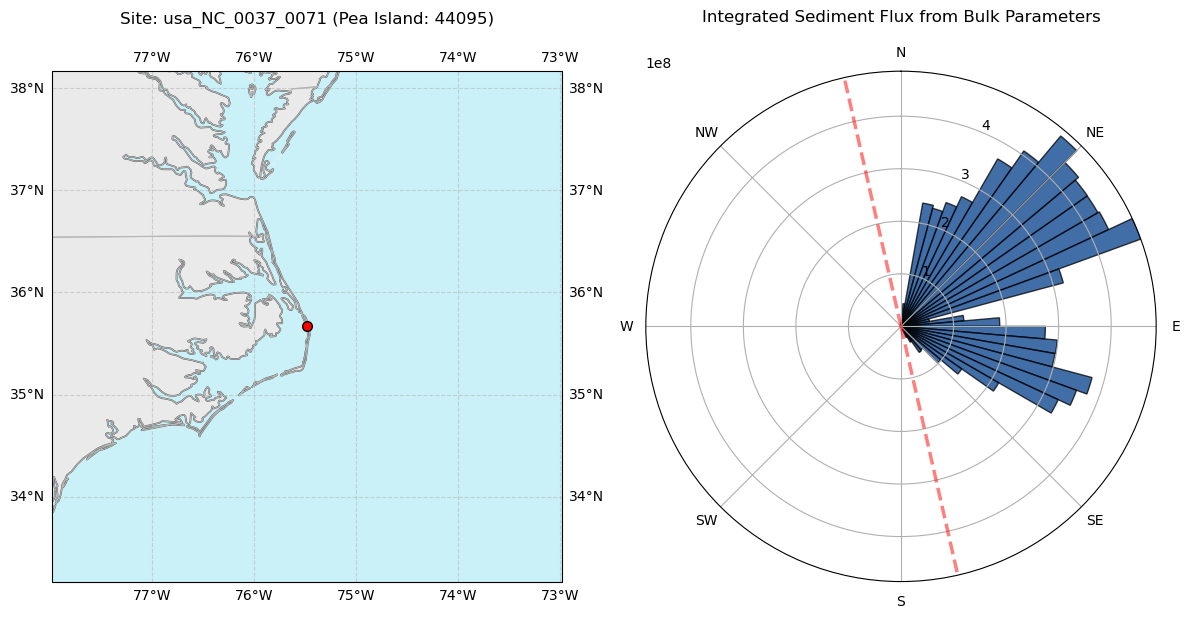

In [5]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Pea Island: 44095)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [6]:
target_site = "usa_NC_0045_0073"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/182952524.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


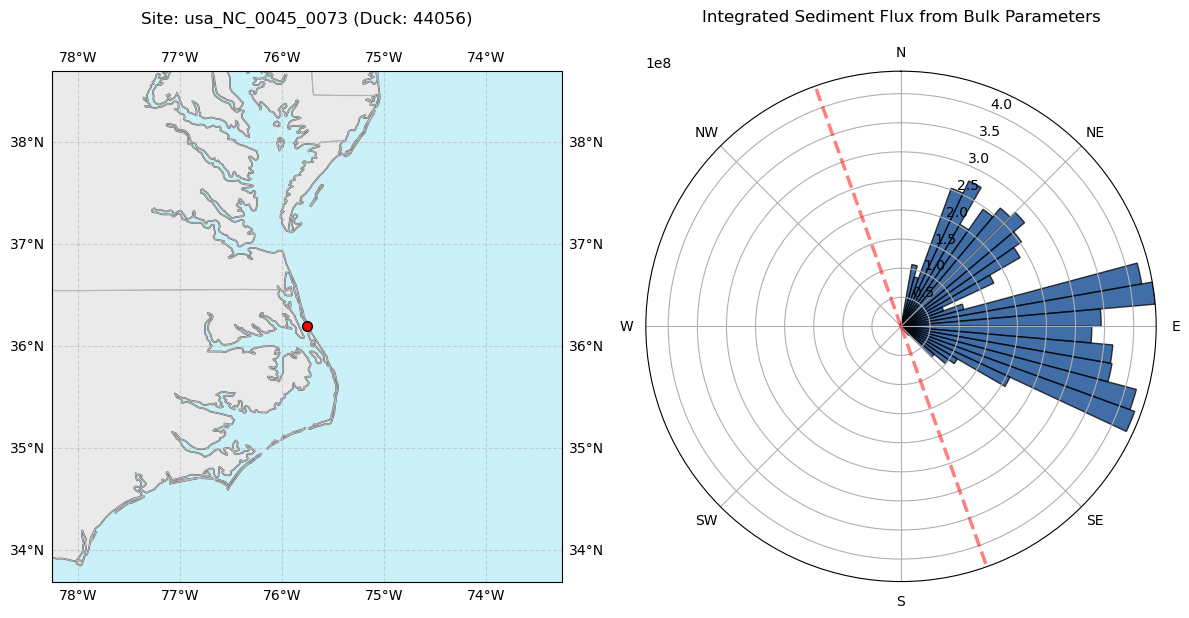

In [7]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Duck: 44056)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [8]:
target_site = "usa_NC_0040_0141"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/2853534692.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


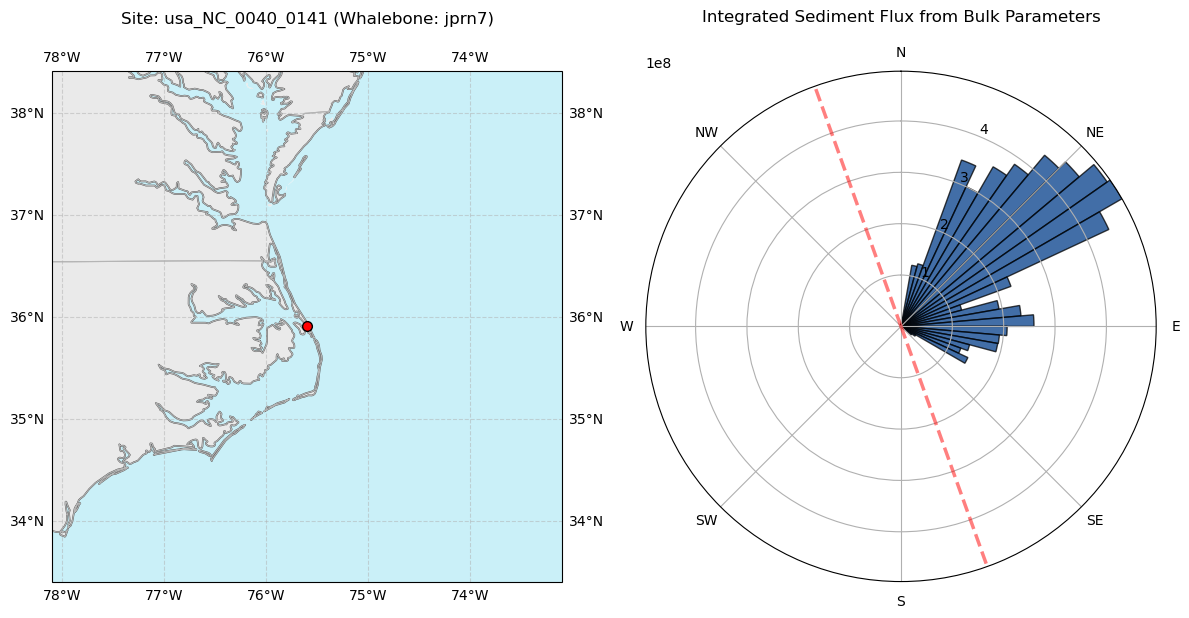

In [9]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Whalebone: jprn7)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [10]:
target_site = "usa_NC_0032_0070"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/2220613867.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


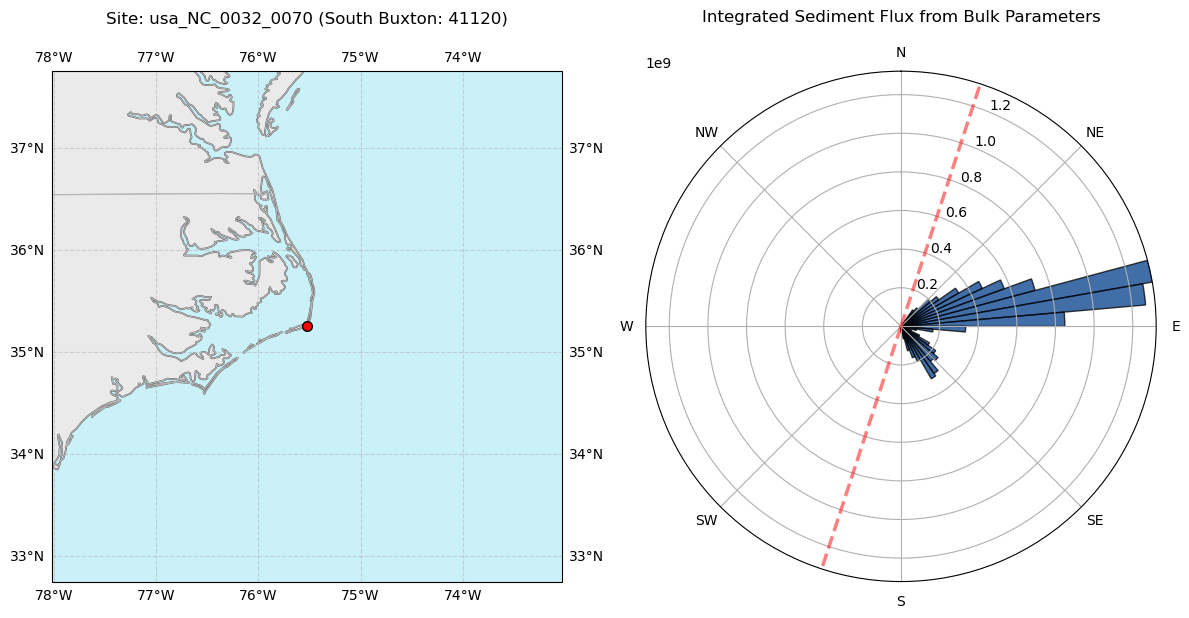

In [11]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (South Buxton: 41120)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [12]:
target_site = "usa_NC_0029_0076"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/952435154.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


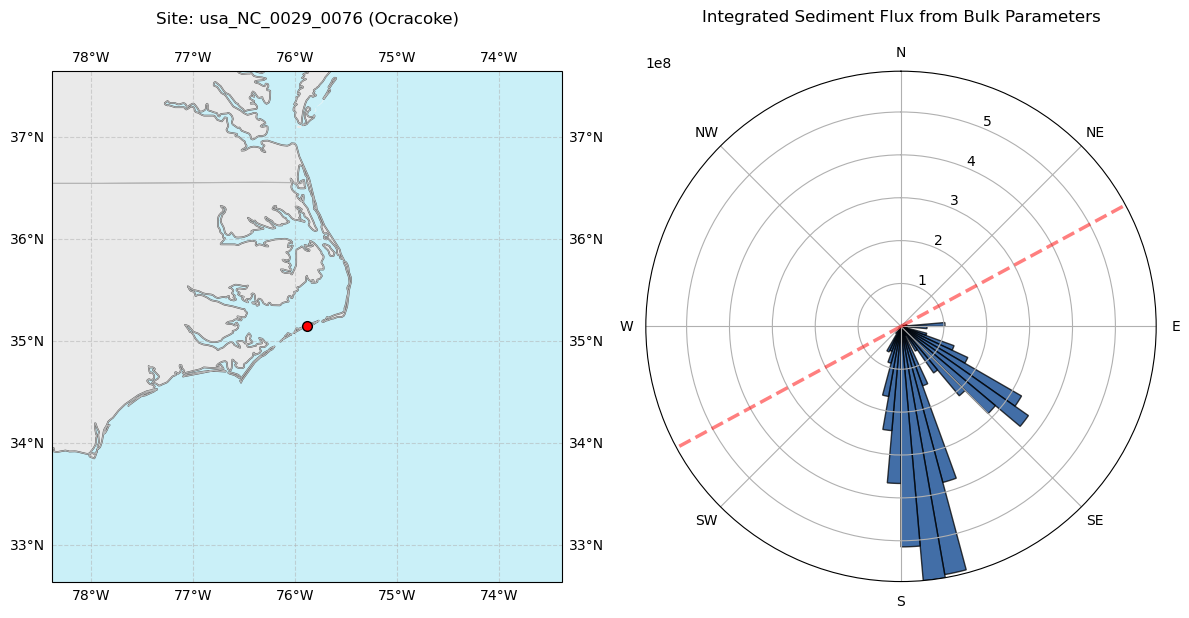

In [13]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Ocracoke)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [14]:
target_site = "usa_NC_0016_0271"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/1374850992.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


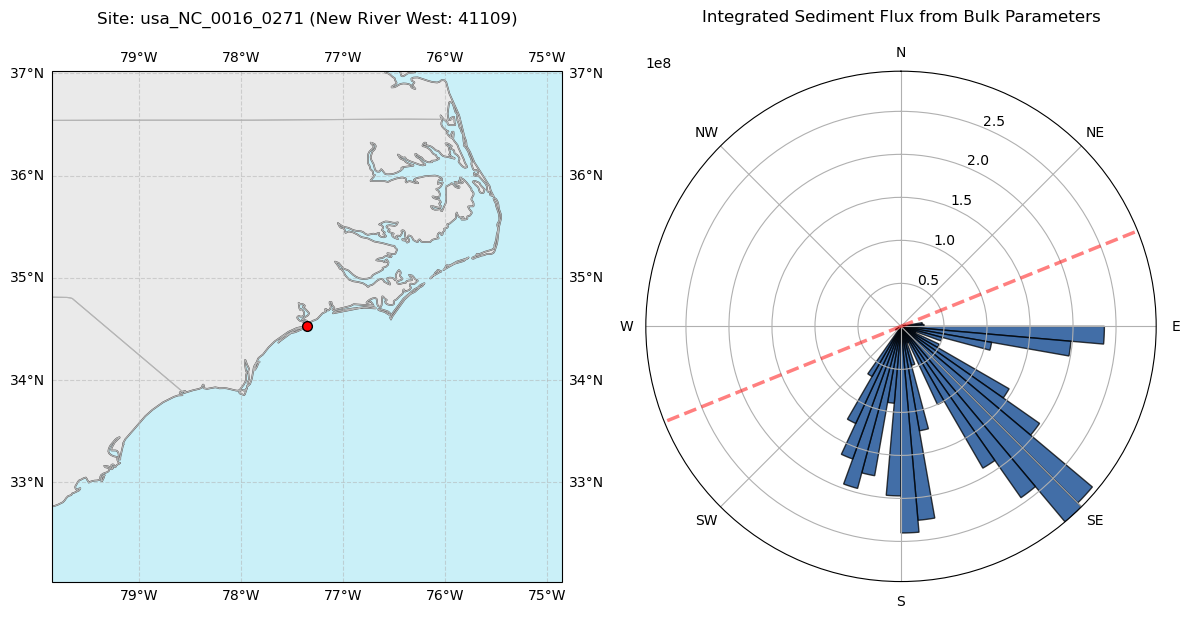

In [15]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (New River West: 41109)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [16]:
target_site = "usa_NC_0010_0136"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/3553532043.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


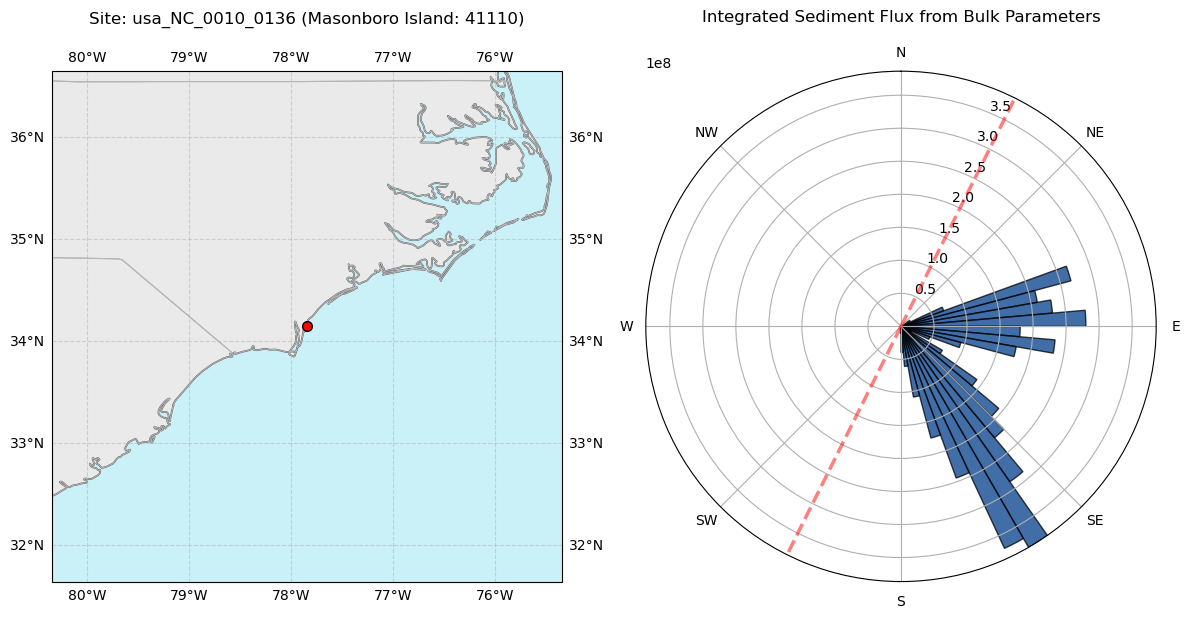

In [17]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Masonboro Island: 41110)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [18]:
target_site = "usa_NC_0001_0098"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/3863834503.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


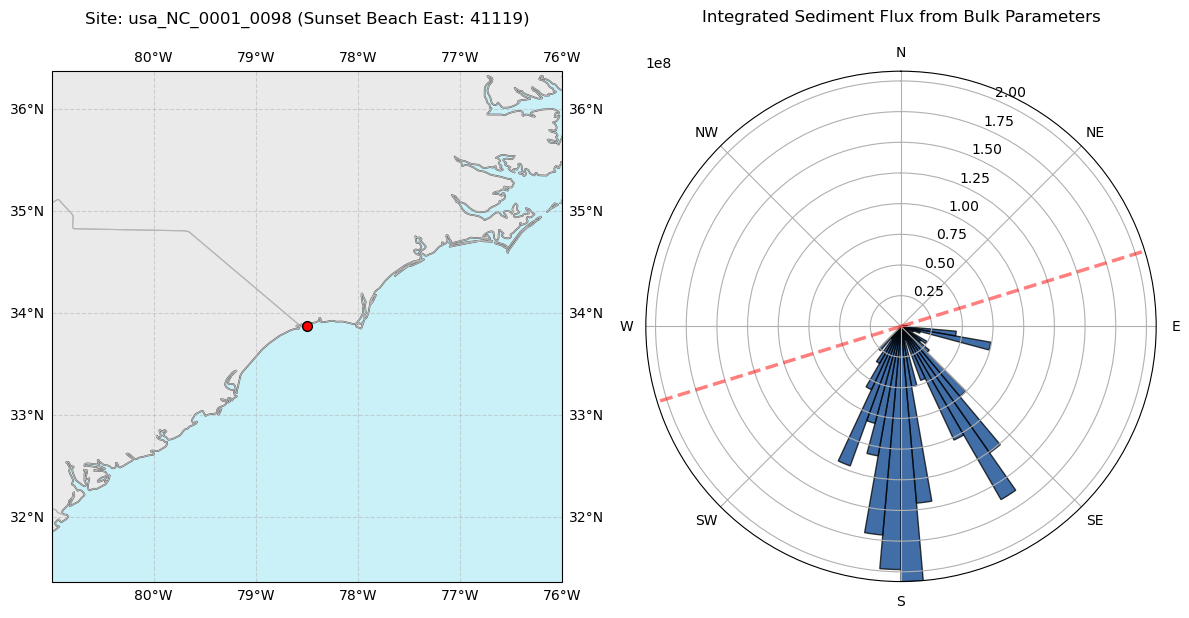

In [19]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Sunset Beach East: 41119)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [20]:
target_site = "usa_NC_0031_0121"

angle = angles['angle'].sel(site=target_site).squeeze()
angle = angle.values.flatten()
angle0 = (angle+180)%360
angle = np.deg2rad(angle)
angle0 = np.deg2rad(angle0)

qs_snapshot = ds['qs'].sel(site=target_site).squeeze()
dp_snapshot = dp_mapped['dp'].sel(site=target_site).squeeze()

dp_vals = dp_snapshot.values.flatten()
qs_vals = qs_snapshot.values.flatten()

mask = ~np.isnan(dp_vals) & ~np.isnan(qs_vals)
dp_vals = dp_vals[mask] % 360
qs_vals = np.abs(qs_vals[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices = np.digitize(dp_vals, bins)
integrated_qs = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs[i-1] = np.sum(qs_vals[bin_indices == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = integrated_qs.max()

/tmp/ipykernel_4056723/1568697154.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


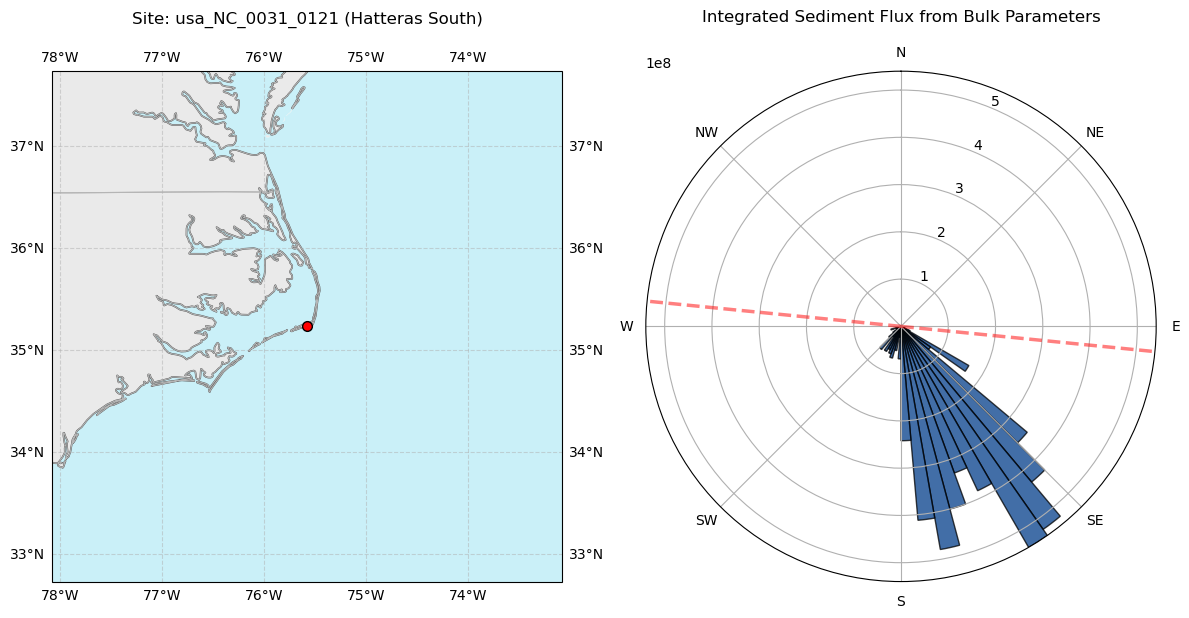

In [21]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 2, 2, projection='polar')                     

ax = [ax0, ax1]

site_lon = float(ds['lon'].sel(site=target_site).values)
site_lat = float(ds['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Hatteras South)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars = ax[1].bar(
    angles_rad, 
    integrated_qs, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

ax[1].axvline(x=angle, color='red', linestyle='--', linewidth=2.5, alpha=.5)
ax[1].axvline(x=angle0, color='red', linestyle='--', linewidth=2.5, alpha=.5)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux from Bulk Parameters', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()